In [1]:
!pip install -q -U transformers datasets accelerate sentencepiece scikit-learn 'pandas==2.2.3' matplotlib
import os
import json
import time
import random
import shutil
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score,
)

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 69.9 MB/s eta 0:00:00
PyTorch: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)
BASE_DIR = Path(
    "/content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison"
)

DATA_DIR = BASE_DIR / "dataset"
DIRS = {
    "results": BASE_DIR / "results",
    "models": BASE_DIR / "models",
    "reports": BASE_DIR / "reports",
    "logs": BASE_DIR / "logs",
    "checkpoints": BASE_DIR / "checkpoints",
    "cache": BASE_DIR / "huggingface_cache",
}

for folder in [DATA_DIR, *DIRS.values()]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(DIRS["cache"])
os.environ["HF_HUB_CACHE"] = str(DIRS["cache"] / "hub")
os.environ["HF_DATASETS_CACHE"] = str(DIRS["cache"] / "datasets")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

TRAIN_CSV = DATA_DIR / "clean_train.csv"
TEST_CSV = DATA_DIR / "clean_test.csv"

print("Experiment folder:", BASE_DIR)
print("Expected training file:", TRAIN_CSV)
print("Expected test file:", TEST_CSV)
print("Training file exists:", TRAIN_CSV.exists())
print("Test file exists:", TEST_CSV.exists())

if not TRAIN_CSV.exists() or not TEST_CSV.exists():
    raise FileNotFoundError(
        "Upload clean_train.csv and clean_test.csv into "
        f"{DATA_DIR} before continuing."
    )

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
Experiment folder: /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison
Expected training file: /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/dataset/clean_train.csv
Expected test file: /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/dataset/clean_test.csv
Training file exists: True
Test file exists: True


In [3]:
# ===== ADD: plots folder aur config =====
DIRS["plots"] = BASE_DIR / "plots"
DIRS["plots"].mkdir(parents=True, exist_ok=True)

# Extra imports (graphs ke liye)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [4]:
train_full = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

required_columns = {"text", "label"}

for name, df in [("clean_train.csv", train_full), ("clean_test.csv", test_df)]:
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")

    if df["text"].isna().any():
        raise ValueError(f"{name} contains missing text values.")
    if df["label"].isna().any():
        raise ValueError(f"{name} contains missing labels.")

    df["text"] = df["text"].astype(str)
    df["label"] = pd.to_numeric(df["label"], errors="raise").astype(int)

allowed_labels = {0, 1}
for name, df in [("clean_train.csv", train_full), ("clean_test.csv", test_df)]:
    found = set(df["label"].unique())
    if not found.issubset(allowed_labels):
        raise ValueError(f"Unexpected labels in {name}: {found}")

if set(train_full["label"].unique()) != allowed_labels:
    raise ValueError("Training CSV must contain both labels 0 and 1.")
if not set(test_df["label"].unique()).issubset(allowed_labels):
    raise ValueError("Test CSV contains labels outside 0 and 1.")

print("Training file shape:", train_full.shape)
print("Test file shape:", test_df.shape)
print("\nTraining label counts:\n", train_full["label"].value_counts().sort_index())
print("\nTest label counts:\n", test_df["label"].value_counts().sort_index())
print("\nSample row:\n", train_full[["text", "label"]].iloc[0].to_dict())

Training file shape: (2823, 2)
Test file shape: (715, 2)

Training label counts:
 label
0    1338
1    1485
Name: count, dtype: int64

Test label counts:
 label
0    346
1    369
Name: count, dtype: int64

Sample row:
 {'text': 'he said he had not felt that way before, suggeted i go rest and so ..trigger ahead if youi re a hypocondriac like me i decide to look up feelings of doom in hopes of maybe getting sucked into some rabbit hole of ludicrous conspiracy, a stupid are you psychic test or new age b.s., something i could even laugh at down the road. no, i ended up reading that this sense of doom can be indicative of various health ailments one of which i am prone to.. so on top of my doom to my gloom..i am now f n worried about my heart. i do happen to have a physical in 48 hours.', 'label': 1}


In [5]:
train_df, val_df = train_test_split(
    train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=train_full["label"],
)

# Reset indexes for clean conversion to Hugging Face Dataset.
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train examples:", len(train_df))
print("Validation examples:", len(val_df))
print("Held-out test examples:", len(test_df))

print("\nTrain label counts:\n", train_df["label"].value_counts().sort_index())
print("\nValidation label counts:\n", val_df["label"].value_counts().sort_index())
print("\nTest label counts:\n", test_df["label"].value_counts().sort_index())

# Save exact split IDs/data so the experiment can be documented and repeated.
train_df.to_csv(DIRS["results"] / "fixed_train_split.csv", index=False)
val_df.to_csv(DIRS["results"] / "fixed_validation_split.csv", index=False)

split_info = {
    "seed": SEED,
    "validation_fraction_of_original_train": 0.10,
    "original_train_rows": len(train_full),
    "train_rows": len(train_df),
    "validation_rows": len(val_df),
    "held_out_test_rows": len(test_df),
    "source_train_csv": str(TRAIN_CSV),
    "source_test_csv": str(TEST_CSV),
}
(DIRS["results"] / "split_info.json").write_text(
    json.dumps(split_info, indent=2),
    encoding="utf-8",
)

print("\nSaved fixed split files and split_info.json.")

Train examples: 2540
Validation examples: 283
Held-out test examples: 715

Train label counts:
 label
0    1204
1    1336
Name: count, dtype: int64

Validation label counts:
 label
0    134
1    149
Name: count, dtype: int64

Test label counts:
 label
0    346
1    369
Name: count, dtype: int64

Saved fixed split files and split_info.json.


In [5]:
MODEL_CONFIGS = {
    "roberta_base": "roberta-base",
    "distilbert_base_uncased": "distilbert-base-uncased",
    "deberta_v3_base": "microsoft/deberta-v3-base",
}

ID2LABEL = {
    0: "label_0",
    1: "label_1",
}
LABEL2ID = {
    "label_0": 0,
    "label_1": 1,
}

MAX_LENGTH = 128
EPOCHS = 3
LEARNING_RATE = 2e-5
BATCH_SIZE = 4

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        )
    )

    precision_weighted, recall_weighted, f1_weighted, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0,
        )
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted,
    }

print("Models to compare:")
for key, model_name in MODEL_CONFIGS.items():
    print(f"{key}: {model_name}")

Models to compare:
roberta_base: roberta-base
distilbert_base_uncased: distilbert-base-uncased
deberta_v3_base: microsoft/deberta-v3-base


In [8]:
all_results = []

for model_key, model_name in MODEL_CONFIGS.items():
    print("\n" + "=" * 80)
    print("Starting:", model_key, "->", model_name)
    print("=" * 80)

    model_output_dir = DIRS["models"] / model_key
    checkpoint_dir = DIRS["checkpoints"] / model_key
    log_dir = DIRS["logs"] / model_key

    model_output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

    # Important fix for DeBERTa:
    # Keep all models in float32 to avoid the previous NaN/zero-loss issue.
    model = model.float()

    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
        )

    hf_data = DatasetDict({
        "train": Dataset.from_pandas(
            train_df[["text", "label"]],
            preserve_index=False
        ),
        "validation": Dataset.from_pandas(
            val_df[["text", "label"]],
            preserve_index=False
        ),
        "test": Dataset.from_pandas(
            test_df[["text", "label"]],
            preserve_index=False
        ),
    })

    tokenized = hf_data.map(
        tokenize_batch,
        batched=True,
        desc=f"Tokenizing for {model_key}",
    )

    tokenized = tokenized.rename_column("label", "labels")

    tokenized.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"],
    )

    training_args = TrainingArguments(
        output_dir=str(checkpoint_dir),

        num_train_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,

        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,

        weight_decay=0.01,

        eval_strategy="epoch",
        save_strategy="epoch",

        logging_strategy="steps",
        logging_steps=50,

        save_total_limit=2,

        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        report_to="none",

        # Important DeBERTa fix
        fp16=False,
        bf16=False,

        # Stable optimizer configuration
        optim="adamw_torch",
        max_grad_norm=1.0,

        seed=SEED,
        data_seed=SEED,

        dataloader_num_workers=2,
    )

    trainer = Trainer(
        model=model,
        args=training_args,

        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],

        processing_class=tokenizer,

        compute_metrics=compute_metrics,

        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ],
    )

    start_time = time.time()

    train_output = trainer.train()

    training_seconds = time.time() - start_time

    # Trainer has selected/restored the best validation checkpoint.
    validation_metrics = trainer.evaluate(
        eval_dataset=tokenized["validation"],
        metric_key_prefix="validation",
    )

    # Evaluate the selected best model on the test set.
    test_metrics = trainer.evaluate(
        eval_dataset=tokenized["test"],
        metric_key_prefix="test",
    )

    # Test predictions
    test_prediction = trainer.predict(
        tokenized["test"]
    )

    test_logits = test_prediction.predictions
    test_true = test_prediction.label_ids

    test_pred = np.argmax(
        test_logits,
        axis=-1
    )

    # Classification report
    report = classification_report(
        test_true,
        test_pred,
        labels=[0, 1],
        target_names=["label_0", "label_1"],
        output_dict=True,
        zero_division=0,
    )

    # Confusion matrix
    cm = confusion_matrix(
        test_true,
        test_pred,
        labels=[0, 1],
    )

    # Save best-validation model and tokenizer
    trainer.save_model(
        str(model_output_dir)
    )

    tokenizer.save_pretrained(
        str(model_output_dir)
    )

    result = {
        "model_key": model_key,
        "model_name": model_name,

        "validation_metrics": validation_metrics,
        "test_metrics": test_metrics,

        "training_seconds": training_seconds,

        "best_checkpoint": trainer.state.best_model_checkpoint,
        "best_validation_macro_f1": trainer.state.best_metric,

        "classification_report": report,

        "confusion_matrix_labels_order": [0, 1],
        "confusion_matrix": cm.tolist(),

        "train_samples": len(train_df),
        "validation_samples": len(val_df),
        "test_samples": len(test_df),

        "seed": SEED,
        "max_length": MAX_LENGTH,
        "epochs_configured": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,

        "fp16": False,
        "bf16": False,
        "optimizer": "adamw_torch",
        "max_grad_norm": 1.0,
    }

    # Save JSON report
    report_path = (
        DIRS["reports"] /
        f"{model_key}_report.json"
    )

    report_path.write_text(
        json.dumps(
            result,
            indent=2,
            default=float
        ),
        encoding="utf-8",
    )

    # Save test predictions
    predictions_df = pd.DataFrame({
        "text": test_df["text"],
        "true_label": test_true,
        "predicted_label": test_pred,
    })

    predictions_df.to_csv(
        DIRS["results"] /
        f"{model_key}_test_predictions.csv",
        index=False,
    )

    all_results.append(result)

    print(
        "\nBest validation macro-F1:",
        trainer.state.best_metric
    )

    print(
        "Test metrics:",
        test_metrics
    )

    print(
        "Test confusion matrix "
        "(rows=true, columns=predicted; labels [0,1]):"
    )

    print(cm)

    print(
        "Training seconds:",
        round(training_seconds, 2)
    )

    print(
        "Saved model:",
        model_output_dir
    )

    print(
        "Saved report:",
        report_path
    )

    # Free GPU memory before next model
    del trainer
    del model
    del tokenizer
    del tokenized
    del hf_data

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print("\nAll three model runs finished.")


Starting: roberta_base -> roberta-base


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizing for roberta_base:   0%|          | 0/2540 [00:00<?, ? examples/s]

Tokenizing for roberta_base:   0%|          | 0/283 [00:00<?, ? examples/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.175191,0.640386,3,0.844523,0.845136,0.842958,0.843662,0.844795,0.844523,0.844277


[transformers] early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.175191,0.709729,3,0.819580,0.822222,0.817997,0.818545,0.821507,0.819580,0.818986


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best validation macro-F1: 0.8436621132985135
Test metrics: {'test_loss': 0.7097291946411133, 'test_accuracy': 0.8195804195804196, 'test_macro_precision': 0.8222222222222222, 'test_macro_recall': 0.8179973996271754, 'test_macro_f1': 0.8185454123377709, 'test_weighted_precision': 0.8215073815073815, 'test_weighted_recall': 0.8195804195804196, 'test_weighted_f1': 0.8189862487559361}
Test confusion matrix (rows=true, columns=predicted; labels [0,1]):
[[266  80]
 [ 49 320]]
Training seconds: 491.51
Saved model: /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/models/deberta_v3_base
Saved report: /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/reports/deberta_v3_base_report.json

All three model runs finished.


In [9]:
comparison_rows = []

for result in all_results:
    val = result["validation_metrics"]
    test = result["test_metrics"]

    comparison_rows.append({
        "model": result["model_name"],
        "model_key": result["model_key"],
        "validation_macro_f1": val.get("validation_macro_f1"),
        "test_accuracy": test.get("test_accuracy"),
        "test_macro_f1": test.get("test_macro_f1"),
        "test_weighted_f1": test.get("test_weighted_f1"),
        "test_macro_precision": test.get("test_macro_precision"),
        "test_macro_recall": test.get("test_macro_recall"),
        "training_seconds": result["training_seconds"],
        "best_checkpoint": result["best_checkpoint"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(
    by="validation_macro_f1",
    ascending=False,
)

display(comparison_df)

comparison_csv = DIRS["results"] / "stress_model_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)

(DIRS["results"] / "all_model_results.json").write_text(
    json.dumps(all_results, indent=2, default=float),
    encoding="utf-8",
)

print("Saved comparison CSV:", comparison_csv)
print("All reports and model folders are under:", BASE_DIR)

,model,model_key,validation_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_macro_precision,test_macro_recall,training_seconds,best_checkpoint
2,microsoft/deberta-v3-base,deberta_v3_base,0.843662,0.819580,0.818545,0.818986,0.822222,0.817997,491.510643,/content/drive/MyDrive/MindCare_AI_Stress_3_Mo...
0,roberta-base,roberta_base,0.833615,0.781818,0.775815,0.776995,0.803503,0.777359,347.904556,/content/drive/MyDrive/MindCare_AI_Stress_3_Mo...
1,distilbert-base-uncased,distilbert_base_uncased,0.805031,0.772028,0.770996,0.771490,0.773234,0.770666,188.993890,/content/drive/MyDrive/MindCare_AI_Stress_3_Mo...


Saved comparison CSV: /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/results/stress_model_comparison.csv
All reports and model folders are under: /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison


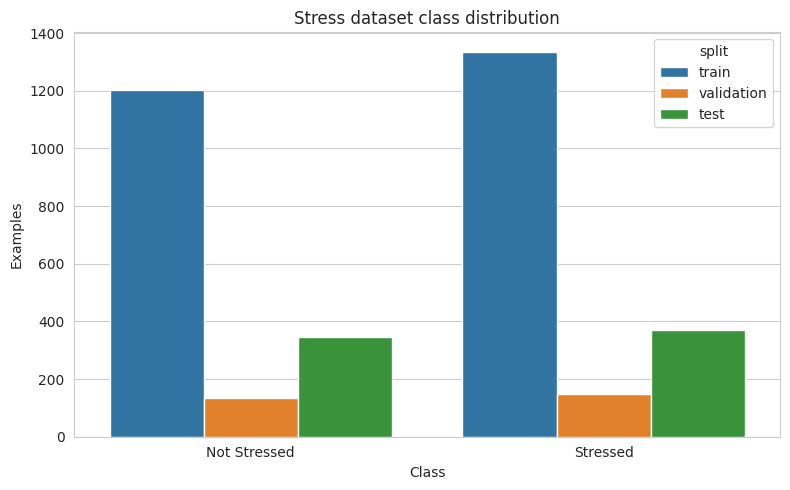

,split,label,label_name,count
0,train,0,Not Stressed,1204
1,train,1,Stressed,1336
2,validation,0,Not Stressed,134
3,validation,1,Stressed,149
4,test,0,Not Stressed,346
5,test,1,Stressed,369


In [6]:
# ===== ADD: Dataset class distribution table + graph =====
distribution_rows = []
for split, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    counts = df["label"].value_counts().to_dict()
    for label_id in [0, 1]:
        distribution_rows.append({
            "split": split,
            "label": label_id,
            "label_name": "Not Stressed" if label_id == 0 else "Stressed",
            "count": int(counts.get(label_id, 0))
        })

distribution_df = pd.DataFrame(distribution_rows)
distribution_df.to_csv(DIRS["reports"] / "dataset_class_distribution.csv", index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=distribution_df, x="label_name", y="count", hue="split")
plt.title("Stress dataset class distribution")
plt.xlabel("Class")
plt.ylabel("Examples")
plt.tight_layout()
plt.savefig(DIRS["plots"] / "dataset_class_distribution.png", dpi=200)
plt.show()

display(distribution_df)

In [7]:
# ===== ADD: Evaluate saved models (no training) =====
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score

def compute_metrics_from_preds(y_true, y_pred):
    """Same as your compute_metrics but takes predictions directly."""
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(p_macro),
        "macro_recall": float(r_macro),
        "macro_f1": float(f_macro),
        "weighted_precision": float(p_weighted),
        "weighted_recall": float(r_weighted),
        "weighted_f1": float(f_weighted),
    }


def evaluate_saved_model(model_key, split="test"):
    """Loads already-trained model from Drive, evaluates on split. NO TRAINING."""
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    import torch

    model_dir = DIRS["models"] / model_key
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir), local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir), local_files_only=True)
    model.to("cuda")
    model.eval()

    frame = {"train": train_df, "validation": val_df, "test": test_df}[split]
    rows = []
    batch_size = 32

    for start in range(0, len(frame), batch_size):
        batch_texts = frame["text"].iloc[start:start + batch_size].tolist()
        inputs = tokenizer(
            batch_texts, truncation=True, max_length=MAX_LENGTH,
            padding=True, return_tensors="pt"
        ).to("cuda")
        with torch.inference_mode():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = probs.argmax(axis=1)
        labels = frame["label"].iloc[start:start + len(batch_texts)].to_numpy()
        for offset, (truth, pred, probability) in enumerate(zip(labels, preds, probs)):
            rows.append({
                "row_id": start + offset,
                "true_label": int(truth),
                "true_class": "Not Stressed" if int(truth) == 0 else "Stressed",
                "predicted_label": int(pred),
                "predicted_class": "Not Stressed" if int(pred) == 0 else "Stressed",
                "confidence": float(probability[int(pred)]),
                "correct": bool(int(truth) == int(pred)),
            })

    pred_df = pd.DataFrame(rows)
    metrics = compute_metrics_from_preds(
        pred_df["true_label"].to_numpy(),
        pred_df["predicted_label"].to_numpy()
    )
    metrics["sample_count"] = int(len(pred_df))

    result_dir = DIRS["results"] / model_key
    result_dir.mkdir(parents=True, exist_ok=True)

    # Save metrics JSON
    with open(result_dir / f"{split}_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    # Save predictions CSV
    pred_df.to_csv(DIRS["results"] / f"{model_key}_{split}_predictions.csv", index=False)

    # Classification report
    report = pd.DataFrame(classification_report(
        pred_df["true_label"], pred_df["predicted_label"],
        labels=[0, 1],
        target_names=["Not Stressed", "Stressed"],
        output_dict=True, zero_division=0
    )).T
    report.index.name = "class"
    report.reset_index().to_csv(result_dir / f"{split}_classification_report.csv", index=False)

    # Confusion matrix
    cm = confusion_matrix(pred_df["true_label"], pred_df["predicted_label"], labels=[0, 1])
    pd.DataFrame(
        cm,
        index=["Not Stressed", "Stressed"],
        columns=["Not Stressed", "Stressed"]
    ).to_csv(result_dir / f"{split}_confusion_matrix.csv")

    del model, tokenizer
    torch.cuda.empty_cache()

    return metrics, pred_df, report, cm


print("✅ evaluate_saved_model() ready. It loads trained models from Drive — no training.")

✅ evaluate_saved_model() ready. It loads trained models from Drive — no training.


In [10]:
# ===== MISSING VARIABLES ADD KARNE WALA CELL =====
MAX_LENGTH = 128
LABEL_NAMES = {0: "Not Stressed", 1: "Stressed"}
SEED = 42

print("✅ MAX_LENGTH =", MAX_LENGTH)
print("✅ LABEL_NAMES =", LABEL_NAMES)
print("✅ SEED =", SEED)

✅ MAX_LENGTH = 128
✅ LABEL_NAMES = {0: 'Not Stressed', 1: 'Stressed'}
✅ SEED = 42


In [12]:
# ===== ADD: Reload training summaries from Drive (no training) =====
# Yeh training cell ko skip karne ke baad bhi comparison_df banayega

MODEL_KEYS = ["roberta_base", "distilbert_base_uncased", "deberta_v3_base"]
MODEL_NAMES = {
    "roberta_base": "roberta-base",
    "distilbert_base_uncased": "distilbert-base-uncased",
    "deberta_v3_base": "microsoft/deberta-v3-base",
}

# Test evaluation (models already trained)
test_outputs = {}
for model_key in MODEL_KEYS:
    try:
        test_outputs[model_key] = evaluate_saved_model(model_key, "test")
        m = test_outputs[model_key][0]
        print(f"{model_key}: acc={m['accuracy']:.4f}  macro_f1={m['macro_f1']:.4f}")
    except Exception as e:
        print(f"⚠️ {model_key}: {e}")

print("\n✅ Test outputs ready.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

roberta_base: acc=0.7818  macro_f1=0.7758


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

distilbert_base_uncased: acc=0.7720  macro_f1=0.7710


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

deberta_v3_base: acc=0.8196  macro_f1=0.8185

✅ Test outputs ready.


In [13]:
# ===== ADD: Final comparison table =====
rows = []
for model_key in MODEL_KEYS:
    if model_key not in test_outputs:
        continue

    # Load validation metrics from saved JSON
    val_json = DIRS["results"] / model_key / "validation_metrics.json"
    if val_json.exists():
        with open(val_json) as f:
            val_metrics = json.load(f)
    else:
        # Fallback: re-evaluate validation
        val_metrics, _, _, _ = evaluate_saved_model(model_key, "validation")

    test_m = test_outputs[model_key][0]

    rows.append({
        "model_key": model_key,
        "base_model": MODEL_NAMES[model_key],
        "validation_accuracy": val_metrics.get("accuracy"),
        "validation_macro_f1": val_metrics.get("macro_f1"),
        "validation_weighted_f1": val_metrics.get("weighted_f1"),
        "test_accuracy": test_m["accuracy"],
        "test_macro_f1": test_m["macro_f1"],
        "test_weighted_f1": test_m["weighted_f1"],
    })

comparison_df = pd.DataFrame(rows).sort_values("validation_macro_f1", ascending=False)
comparison_df.to_csv(DIRS["reports"] / "three_model_comparison.csv", index=False)
display(comparison_df)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

,model_key,base_model,validation_accuracy,validation_macro_f1,validation_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1
2,deberta_v3_base,microsoft/deberta-v3-base,0.844523,0.843662,0.844277,0.819580,0.818545,0.818986
0,roberta_base,roberta-base,0.837456,0.833615,0.834955,0.781818,0.775815,0.776995
1,distilbert_base_uncased,distilbert-base-uncased,0.805654,0.805031,0.805615,0.772028,0.770996,0.771490


In [14]:
# ===== ADD: Selected production model (from validation) =====
selected_row = comparison_df.iloc[0]
selected_model_key = selected_row["model_key"]
selected_model_name = selected_row["base_model"]

selection = {
    "selection_rule": "highest validation Macro-F1",
    "selected_model_key": selected_model_key,
    "selected_base_model": selected_model_name,
    "validation_macro_f1": float(selected_row["validation_macro_f1"]),
    "test_set_used_for_selection": False,
}

with open(DIRS["reports"] / "selected_model.json", "w") as f:
    json.dump(selection, f, indent=2)

print(f"✅ Selected: {selected_model_name} ({selected_model_key})")
print(f"   Validation Macro-F1: {selection['validation_macro_f1']:.4f}")

✅ Selected: microsoft/deberta-v3-base (deberta_v3_base)
   Validation Macro-F1: 0.8437


/tmp/ipykernel_1673/895144383.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="model_key", y=metric, palette="viridis")


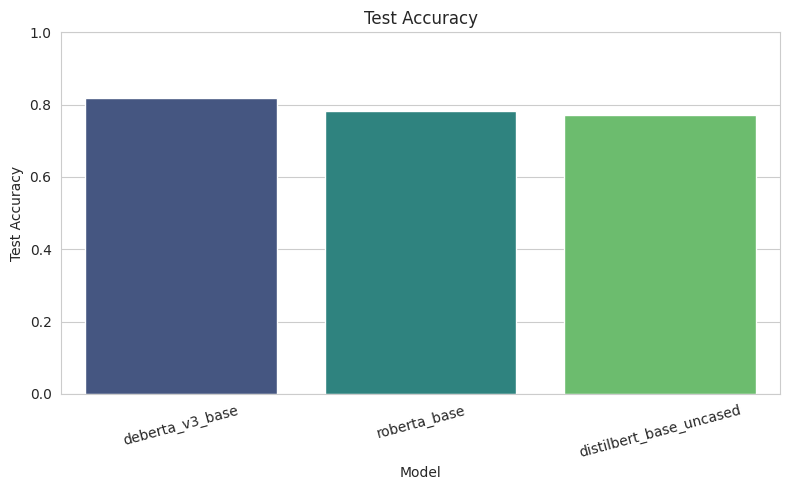

/tmp/ipykernel_1673/895144383.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="model_key", y=metric, palette="viridis")


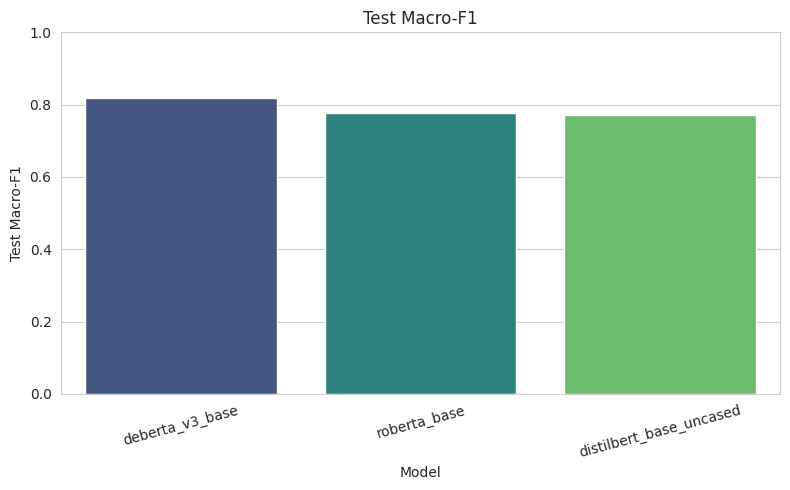

/tmp/ipykernel_1673/895144383.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="model_key", y=metric, palette="viridis")


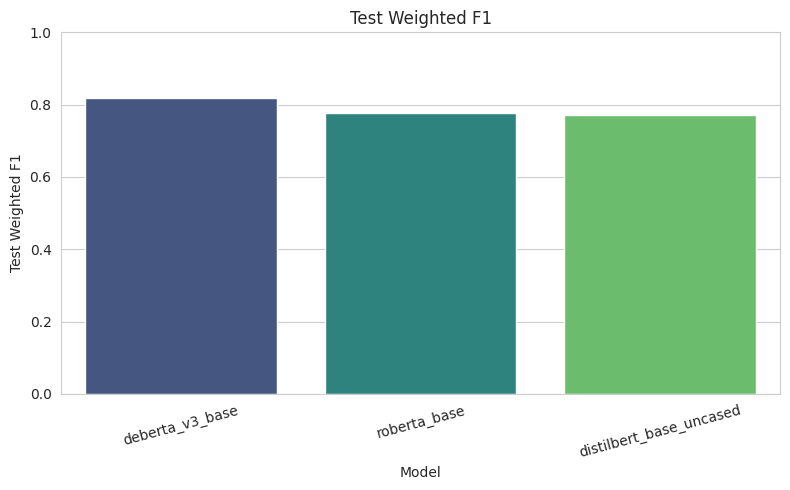

/tmp/ipykernel_1673/895144383.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="model_key", y=metric, palette="viridis")


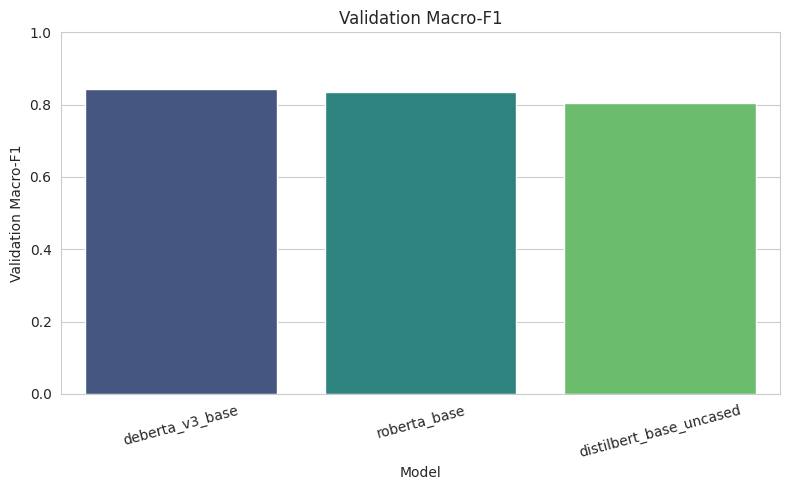

In [15]:
# ===== ADD: Comparison bar charts =====
for metric, title in [
    ("test_accuracy", "Test Accuracy"),
    ("test_macro_f1", "Test Macro-F1"),
    ("test_weighted_f1", "Test Weighted F1"),
    ("validation_macro_f1", "Validation Macro-F1"),
]:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=comparison_df, x="model_key", y=metric, palette="viridis")
    plt.ylim(0, 1)
    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(title)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(DIRS["plots"] / f"comparison_{metric}.png", dpi=200)
    plt.show()

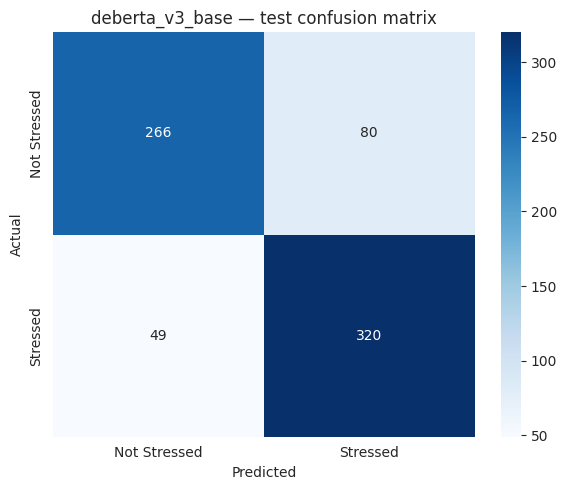

,class,precision,recall,f1-score,support
0,Not Stressed,0.844444,0.768786,0.804841,346.00000
1,Stressed,0.800000,0.867209,0.832250,369.00000
2,accuracy,0.819580,0.819580,0.819580,0.81958
3,macro avg,0.822222,0.817997,0.818545,715.00000
4,weighted avg,0.821507,0.819580,0.818986,715.00000


In [16]:
# ===== ADD: Confusion matrix heatmap for selected model =====
_, _, best_report, best_cm = test_outputs[selected_model_key]

plt.figure(figsize=(6, 5))
sns.heatmap(
    best_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not Stressed", "Stressed"],
    yticklabels=["Not Stressed", "Stressed"]
)
plt.title(f"{selected_model_key} — test confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(DIRS["plots"] / "selected_model_test_confusion_matrix.png", dpi=200)
plt.show()

# Display per-class report
selected_test_report = pd.read_csv(
    DIRS["results"] / selected_model_key / "test_classification_report.csv"
)
display(selected_test_report)

In [17]:
# ===== ADD: Error summary for selected model =====
best_pred = test_outputs[selected_model_key][1]

error_summary = (
    best_pred.loc[~best_pred["correct"]]
    .groupby(["true_class", "predicted_class"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_summary.to_csv(DIRS["reports"] / "selected_model_error_summary.csv", index=False)

print("Selected-model errors by class pair:")
display(error_summary)

Selected-model errors by class pair:


,true_class,predicted_class,count
0,Not Stressed,Stressed,80
1,Stressed,Not Stressed,49


/tmp/ipykernel_1673/1915889513.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_df, x="model_key", y="training_time_min", palette="magma")


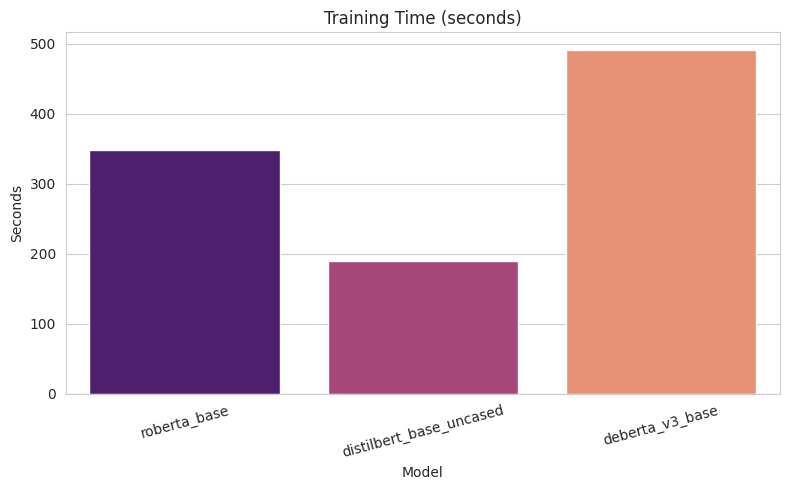

In [22]:
# ===== ADD: Training time bar chart =====
# Note: training_time_min aapki saved JSON se aayega
# Agar nahi mila, toh manual values daalein (apni stress run se)

training_times = {
    "roberta_base": 347.9,              # ← apni actual value daalein
    "distilbert_base_uncased": 188.99,   # ← apni actual value daalein
    "deberta_v3_base": 491.51,           # ← apni actual value daalein
}

time_df = pd.DataFrame([
    {"model_key": k, "training_time_min": v}
    for k, v in training_times.items()
])

plt.figure(figsize=(8, 5))
sns.barplot(data=time_df, x="model_key", y="training_time_min", palette="magma")
plt.title("Training Time (seconds)")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(DIRS["plots"] / "comparison_training_time.png", dpi=200)
plt.show()

In [20]:
# ===== ADD: Save final report and Excel workbook =====
report_lines = [
    "# Stress dataset: three-model comparison", "",
    "Task: binary text classification (0 = Not Stressed, 1 = Stressed).",
    "Selection criterion: validation Macro-F1; test set was not used for selection.",
    "",
    f"Selected production model: **{selected_model_name}** ({selected_model_key}).",
    f"Validation Macro-F1: **{selection['validation_macro_f1']:.4f}**.",
    "",
    "## Results", "",
    comparison_df.to_markdown(index=False), "",
    "## Important limitations", "",
    "This is a benchmark on the supplied dataset, not clinical validation.",
    "Do not use predictions to diagnose or replace professional care.",
]

(DIRS["reports"] / "COMPLETE_EXPERIMENT_REPORT.md").write_text(
    "\n".join(report_lines), encoding="utf-8"
)

# Excel export
with pd.ExcelWriter(
    DIRS["reports"] / "stress_three_model_comparison.xlsx",
    engine="openpyxl"
) as writer:
    comparison_df.to_excel(writer, sheet_name="Comparison", index=False)
    if 'distribution_df' in dir():
        distribution_df.to_excel(writer, sheet_name="Class Distribution", index=False)
    if 'selected_test_report' in dir():
        selected_test_report.to_excel(writer, sheet_name="Selected Model Test", index=False)
    if 'error_summary' in dir():
        error_summary.to_excel(writer, sheet_name="Selected Model Errors", index=False)

print("✅ Report and Excel saved.")
print((DIRS["reports"] / "COMPLETE_EXPERIMENT_REPORT.md").read_text(encoding="utf-8"))

✅ Report and Excel saved.
# Stress dataset: three-model comparison

Task: binary text classification (0 = Not Stressed, 1 = Stressed).
Selection criterion: validation Macro-F1; test set was not used for selection.

Selected production model: **microsoft/deberta-v3-base** (deberta_v3_base).
Validation Macro-F1: **0.8437**.

## Results

| model_key               | base_model                |   validation_accuracy |   validation_macro_f1 |   validation_weighted_f1 |   test_accuracy |   test_macro_f1 |   test_weighted_f1 |
|:------------------------|:--------------------------|----------------------:|----------------------:|-------------------------:|----------------:|----------------:|-------------------:|
| deberta_v3_base         | microsoft/deberta-v3-base |              0.844523 |              0.843662 |                 0.844277 |        0.81958  |        0.818545 |           0.818986 |
| roberta_base            | roberta-base              |              0.837456 |              0.8336

In [21]:
# ===== ADD: Final checklist =====
required = [
    DIRS["models"] / selected_model_key / "config.json",
    DIRS["models"] / selected_model_key / "model.safetensors",
    DIRS["reports"] / "three_model_comparison.csv",
    DIRS["reports"] / "selected_model.json",
    DIRS["reports"] / "COMPLETE_EXPERIMENT_REPORT.md",
    DIRS["plots"] / "comparison_test_macro_f1.png",
    DIRS["plots"] / "selected_model_test_confusion_matrix.png",
    DIRS["plots"] / "dataset_class_distribution.png",
]

for path in required:
    status = "OK      " if path.exists() else "MISSING "
    print(status + str(path))

if any(not p.exists() for p in required):
    print("\n⚠️  Some artifacts missing — check paths.")
else:
    print("\n✅ All artifacts present.")

OK      /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/models/deberta_v3_base/config.json
OK      /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/models/deberta_v3_base/model.safetensors
OK      /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/reports/three_model_comparison.csv
OK      /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/reports/selected_model.json
OK      /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/reports/COMPLETE_EXPERIMENT_REPORT.md
OK      /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/plots/comparison_test_macro_f1.png
OK      /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/plots/selected_model_test_confusion_matrix.png
OK      /content/drive/MyDrive/MindCare_AI_Stress_3_Model_Comparison/plots/dataset_class_distribution.png

✅ All artifacts present.
